# 02 · Machine Learning with Scikit-Learn

> 🇪🇸 Versión en español: [`02_scikit_learn.ipynb`](02_scikit_learn.ipynb)

Scikit-learn always follows the same pattern: `model.fit(X, y)` → `model.predict(X_new)`.
In this notebook we build a **complete and correct** workflow:

1. Split *train* / *test* **before** touching the data.
2. Preprocess with `ColumnTransformer` + `Pipeline` (avoids *data leakage*).
3. Compare models with cross-validation.
4. Tune hyperparameters with `GridSearchCV`.
5. Evaluate once on *test* and interpret.
6. Bonus: classification.

The data is loaded with **Polars**, which scikit-learn accepts directly.

In [1]:
# Libraries
#=====================================================
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("scikit-learn", sklearn.__version__)
SEED = 42

scikit-learn 1.9.1


## 1. Load data and split train / test

In [2]:
df = pl.read_csv("datos/houses.csv")

X = df.drop("id", "price")
y = df["price"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(X_train.shape, X_test.shape)
X_train.head()

(1600, 6) (400, 6)


neighborhood,sqm,rooms,age,distance_center_km,has_garage
str,f64,i64,f64,f64,str
"""South""",87.4,1,null,24.08,"""no"""
"""Outskirts""",45.0,1,32.0,9.18,"""yes"""
"""North""",95.0,3,35.0,4.48,"""no"""
"""North""",92.0,2,1.0,4.78,"""no"""
"""South""",35.0,1,2.0,5.16,"""no"""


## 2. Preprocessing inside a Pipeline

- **Numeric**: impute missing values with the median → standardize (mean 0, std 1).
- **Categorical**: one-hot encoding.

By putting everything in a `Pipeline`, the median and the scale are computed **only on the training data**
of each *fold*, so the evaluation is honest.

In [3]:
numeric = ["sqm", "rooms", "age", "distance_center_km"]
categorical = ["neighborhood", "has_garage"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
])

# See what it produces (returned as Polars so it's easy to read)
preprocessor.set_output(transform="polars")
preprocessor.fit_transform(X_train).head()

num__sqm,num__rooms,num__age,num__distance_center_km,cat__neighborhood_Downtown,cat__neighborhood_North,cat__neighborhood_Outskirts,cat__neighborhood_South,cat__has_garage_no,cat__has_garage_yes
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-0.694688,-1.686346,-0.014466,1.681431,0.0,0.0,0.0,1.0,1.0,0.0
-1.943254,-1.686346,0.162669,-0.255379,0.0,0.0,1.0,0.0,0.0,1.0
-0.470888,-0.142338,0.339804,-0.866319,0.0,1.0,0.0,0.0,1.0,0.0
-0.55923,-0.914342,-1.667726,-0.827322,0.0,1.0,0.0,0.0,1.0,0.0
-2.237727,-1.686346,-1.608681,-0.777927,0.0,0.0,0.0,1.0,1.0,0.0


## 3. Compare models with cross-validation (5 folds)

In [4]:
models = {
    "Linear regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingRegressor(random_state=SEED),
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
results = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    s = cross_validate(pipe, X_train, y_train, cv=cv,
                       scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"})
    results.append({"model": name,
                    "RMSE": -s["test_rmse"].mean(),
                    "RMSE_std": s["test_rmse"].std(),
                    "R2": s["test_r2"].mean()})

pl.DataFrame(results).sort("RMSE")

model,RMSE,RMSE_std,R2
str,f64,f64,f64
"""Gradient Boosting""",24444.234119,1426.716486,0.94533
"""Random Forest""",26889.914201,1804.69204,0.933808
"""KNN (k=5)""",29337.227394,1697.720782,0.921157
"""Linear regression""",33125.502468,1180.957548,0.899617
"""Ridge""",33125.990239,1166.73176,0.899617


## 4. Hyperparameter tuning

`GridSearchCV` tries every combination with cross-validation.
Parameters of a pipeline step are named `step__parameter`.

In [5]:
pipe_gb = Pipeline([("prep", preprocessor),
                    ("model", HistGradientBoostingRegressor(random_state=SEED))])

grid = GridSearchCV(
    pipe_gb,
    param_grid={
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [None, 4, 8],
        "model__max_iter": [200, 400],
    },
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
print(f"CV RMSE: {-grid.best_score_:,.0f}")

Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__max_iter': 400}
CV RMSE: 23,553


## 5. Final evaluation on test (only once)

MAE : 15,398
RMSE: 20,082
R²  : 0.960


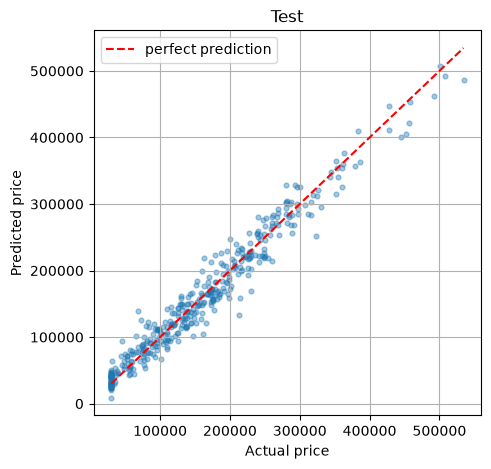

In [6]:
best = grid.best_estimator_
pred = best.predict(X_test)

print(f"MAE : {mean_absolute_error(y_test, pred):,.0f}")
print(f"RMSE: {root_mean_squared_error(y_test, pred):,.0f}")
print(f"R²  : {r2_score(y_test, pred):.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, pred, alpha=0.4, s=12)
lim = [y_test.min(), y_test.max()]
ax.plot(lim, lim, "r--", label="perfect prediction")
ax.set(xlabel="Actual price", ylabel="Predicted price", title="Test")
ax.legend(); ax.grid(True)
plt.show()

### Which features matter?
*Permutation importance*: how much worse the model gets when a column is shuffled.

In [7]:
# permutation_importance doesn't accept Polars yet: we pass Pandas
imp = permutation_importance(best, X_test.to_pandas(), y_test, n_repeats=10, random_state=SEED,
                             scoring="neg_root_mean_squared_error")
pl.DataFrame({"feature": X_test.columns, "importance": imp.importances_mean}).sort("importance", descending=True)

feature,importance
str,f64
"""sqm""",68849.895504
"""age""",44329.700235
"""neighborhood""",35372.642645
"""distance_center_km""",28458.852881
"""rooms""",8927.604566
"""has_garage""",3376.877005


### Save and load the model

In [8]:
import joblib

joblib.dump(best, "house_model.joblib")
loaded = joblib.load("house_model.joblib")

new_house = pl.DataFrame({
    "neighborhood": ["North"], "sqm": [120.0], "rooms": [3], "age": [10.0],
    "distance_center_km": [6.5], "has_garage": ["yes"],
})
print(f"Estimated price: {loaded.predict(new_house)[0]:,.0f}")

Estimated price: 256,914


## 6. Bonus: classification

Same pattern, different task: predict whether a house is **expensive** (price above the median).
The model and the metrics change.

              precision    recall  f1-score   support

       cheap       0.94      0.94      0.94       190
   expensive       0.94      0.94      0.94       210

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



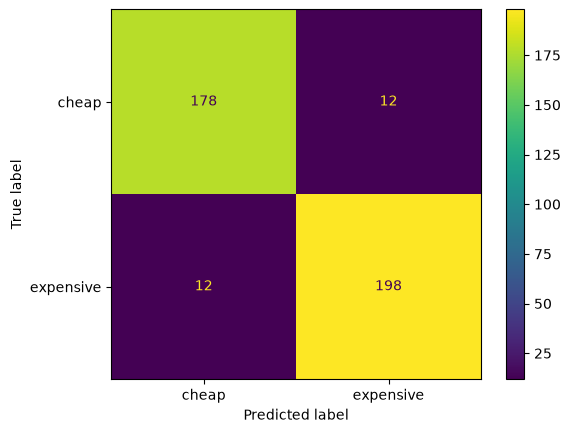

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

threshold = np.median(y_train)
yc_train, yc_test = (y_train > threshold).astype(int), (y_test > threshold).astype(int)

clf = Pipeline([("prep", preprocessor), ("model", LogisticRegression(max_iter=1000))])
clf.fit(X_train, yc_train)
pred_c = clf.predict(X_test)

print(classification_report(yc_test, pred_c, target_names=["cheap", "expensive"]))
ConfusionMatrixDisplay.from_predictions(yc_test, pred_c, display_labels=["cheap", "expensive"])
plt.show()

## Summary
- `train_test_split` first; the *test* set is not touched until the end.
- `Pipeline` + `ColumnTransformer` = leak-free, reproducible preprocessing.
- `cross_validate` to compare, `GridSearchCV` to tune.
- Metrics: regression (MAE, RMSE, R²), classification (precision, recall, F1, confusion matrix).

## ✏️ Exercises
1. Add a `sqm_per_room` feature (with Polars, before the split) and check whether RMSE improves.
2. Try `RandomizedSearchCV` on `RandomForestRegressor` (`n_estimators`, `max_depth`, `min_samples_leaf`).
3. For the classification task, try `RandomForestClassifier` and compare using `roc_auc_score`.
4. Compare with your linear regression and KNN notebook at the repo root: why does KNN need scaling here?